<a href="https://colab.research.google.com/github/anapauuu31/M2.Analisis_Desempe-o/blob/main/M2_Analisis_Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de "Placement" mediante Random Forest

## Análisis Exploratorio de Datos

Este análisis tiene como objetivo explorar el conjunto de datos que contiene información académica y no académica de estudiantes universitarios, incluyendo su desempeño académico, experiencia en pasantías, habilidades y resultado de colocación laboral (Placement).

### 1. Carga y vista general del dataset

En esta sección se carga el archivo "college_student_placement_dataset.csv y se realiza" una primera inspección visual de los datos, además de revisar las dimensiones del dataset y el nombre de sus columnas. Esto permite confirmar que el archivo se cargó correctamente y tener una primera idea de las variables disponibles.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [29]:
df = pd.read_csv("/content/college_student_placement_dataset.csv")

In [30]:
df.head(5)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [31]:
print(df.shape)
print(df.columns.tolist())

(10000, 10)
['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']


### Observación

El dataset contiene 10,000 registros y 10 columnas: College_ID, IQ, Prev_Sem_Result, CGPA, Academic_Performance, Internship_Experience, Extra_Curricular_Score, Communication_Skills, Projects_Completed y Placement (variable objetivo). College_ID funciona únicamente como identificador del estudiante y no aporta información predictiva, por lo que será excluido más adelante del modelo.

### 2. Exploración general del dataset

Se revisan las dimensiones, tipos de datos, valores faltantes, registros duplicados y cantidad de valores únicos para conocer la estructura y calidad de los datos.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [33]:
missing = df.isnull().sum()

print(missing[missing > 0])

print("\nTotal de valores faltantes:", missing.sum())

Series([], dtype: int64)

Total de valores faltantes: 0


In [34]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [35]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

College_ID: 100 valores únicos
IQ: 104 valores únicos
Prev_Sem_Result: 501 valores únicos
CGPA: 590 valores únicos
Academic_Performance: 10 valores únicos
Internship_Experience: 2 valores únicos
Extra_Curricular_Score: 11 valores únicos
Communication_Skills: 10 valores únicos
Projects_Completed: 6 valores únicos
Placement: 2 valores únicos


In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
IQ,10000.0,99.471800,15.053101,41.00,89.00,99.00,110.00,158.00
Prev_Sem_Result,10000.0,7.535673,1.447519,5.00,6.29,7.56,8.79,10.00
CGPA,10000.0,7.532379,1.470141,4.54,6.29,7.55,8.77,10.46
Academic_Performance,10000.0,5.546400,2.873477,1.00,3.00,6.00,8.00,10.00
Extra_Curricular_Score,10000.0,4.970900,3.160103,0.00,2.00,5.00,8.00,10.00
Communication_Skills,10000.0,5.561800,2.900866,1.00,3.00,6.00,8.00,10.00
Projects_Completed,10000.0,2.513400,1.715959,0.00,1.00,3.00,4.00,5.00


### Observación

El dataset no presenta valores faltantes ni filas duplicadas, por lo que no fue necesario aplicar procesos de limpieza adicionales. Internship Experience y Placement son las únicas variables de tipo texto (Yes/No); el resto son variables numéricas. En cuanto a las estadísticas descriptivas, IQ (media ≈ 99.5, rango 41–158) y CGPA (media ≈ 7.53, rango 4.54–10.46) presentan distribuciones aproximadamente simétricas, ya que sus valores de media y mediana son muy cercanos. Variables como Academic_Performance, Communication_Skills y Extra_Curricular_Score se mueven en escalas de calificación (0–10), mientras que Projects_Completed tiene un rango más acotado (0–5).


### 3. Análisis de la variable objetivo

La variable Placement indica si el estudiante logró obtener una colocación laboral (Yes/No).

Se analiza su distribución para determinar si existe un desbalance entre las clases.

Placement
No     8341
Yes    1659
Name: count, dtype: int64

Porcentajes:
Placement
No     83.41
Yes    16.59
Name: proportion, dtype: float64


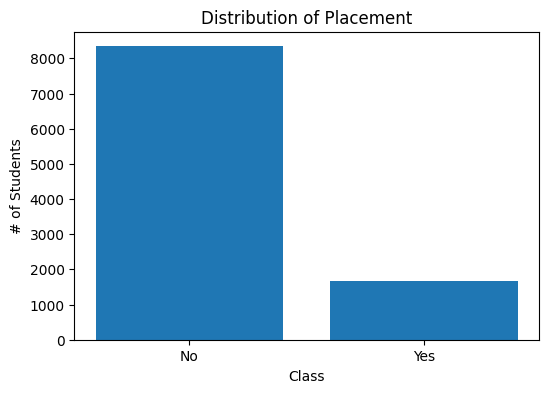

In [37]:
target = "Placement"

print(df[target].value_counts())
print("\nPorcentajes:")
print(df[target].value_counts(normalize=True) * 100)

counts = df[target].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribution of Placement")
plt.xlabel("Class")
plt.ylabel("# of Students")
plt.show()

In [38]:
df[target].value_counts()
df[target].value_counts(normalize=True) * 100

,proportion
Placement,
No,83.41
Yes,16.59


### Observación

El 83.41% de los estudiantes pertenece a la clase **No Placement**, mientras que el 16.59% pertenece a **Placement**. Por lo tanto, existe un desbalance considerable entre las clases, incluso más marcado que en el dataset de tarjetas de crédito original.

Esto deberá considerarse durante la evaluación del modelo, ya que la exactitud (accuracy) por sí sola podría dar una impresión engañosa de su desempeño. Será importante complementar esta métrica con la matriz de confusión, precision, recall y F1-score.

### 4. Análisis de variables categóricas

Internship_Experience es la única variable categórica de texto (Yes/No) entre las variables predictoras. Placement también es texto, pero corresponde a la variable objetivo y se codificará más adelante junto con Internship_Experience durante el preprocesamiento.

Se revisa la distribución de Internship_Experience y su relación con la tasa de colocación, para identificar si haber tenido una pasantía está asociado con una mayor probabilidad de ser colocado.

Internship_Experience
No     6036
Yes    3964
Name: count, dtype: int64


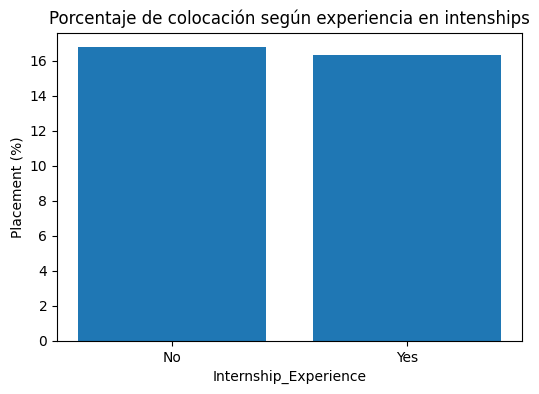

In [47]:
print(df["Internship_Experience"].value_counts())

# Porcentaje de colocación según si tuvo pasantía o no
placement_by_intern = (
    df.assign(Placement_bin=(df["Placement"] == "Yes").astype(int))
    .groupby("Internship_Experience")["Placement_bin"]
    .mean() * 100
)

plt.figure(figsize=(6, 4))
plt.bar(placement_by_intern.index.astype(str), placement_by_intern.values)
plt.title("Porcentaje de colocación según experiencia en intenships")
plt.xlabel("Internship_Experience")
plt.ylabel("Placement (%)")
plt.show()

### Observación


De los 10,000 estudiantes, 6,036 no tienen experiencia en pasantías y 3,964 sí la tienen. A partir del gráfico de barras se observa que el grupo con experiencia en pasantías presenta una proporción de colocación más alta que el grupo sin experiencia, lo que sugiere que esta variable podría aportar valor predictivo al modelo.

### 5. Análisis de variables numéricas

Se analiza la distribución de las variables numéricas más relevantes para comprender las características académicas generales de los estudiantes.

En particular, se examinan CGPA e IQ mediante histogramas, con el objetivo de observar su distribución, concentración y posibles valores extremos.

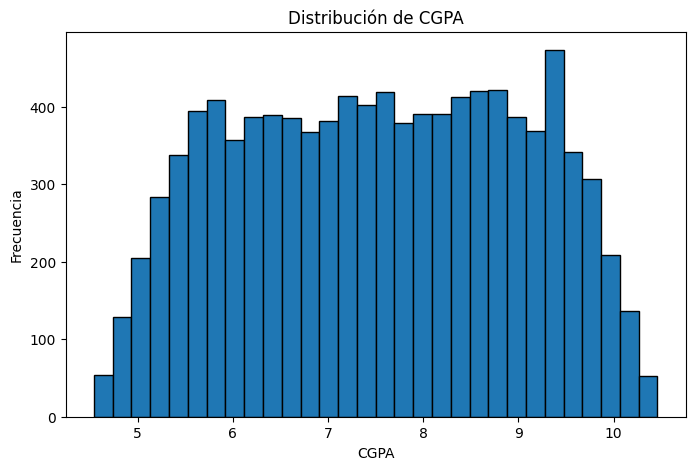

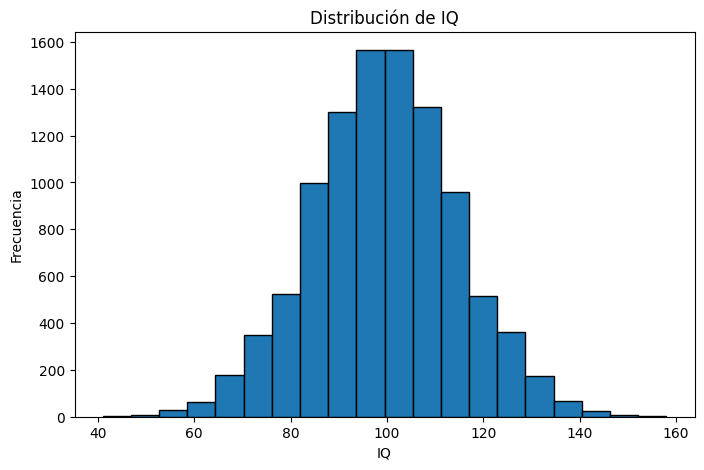

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(df["CGPA"], bins=30, edgecolor="black")
plt.title("Distribución de CGPA")
plt.xlabel("CGPA")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["IQ"], bins=20, edgecolor="black")
plt.title("Distribución de IQ")
plt.xlabel("IQ")
plt.ylabel("Frecuencia")
plt.show()

### Observación

Tanto CGPA como IQ presentan distribuciones aproximadamente simétricas (campana), a diferencia del dataset de tarjetas de crédito, donde LIMIT_BAL y AGE mostraban un sesgo hacia la derecha.

CGPA se concentra alrededor de 7.5 (mediana 7.55, con la mayoría de los valores entre 6.29 y 8.77), y IQ se concentra alrededor de 99 (mediana 99, con la mayoría de los valores entre 89 y 110). No se observan valores extremos evidentes en ninguna de las dos variables.

### 6. Relación entre el desempeño académico y la colocación

El desempeño académico puede aportar información relevante para identificar la probabilidad de colocación de un estudiante.

A continuación, se analiza el porcentaje de estudiantes colocados según su nivel de Academic_Performance. Esto permite observar si existen diferencias en la proporción de colocación entre los distintos niveles de desempeño.


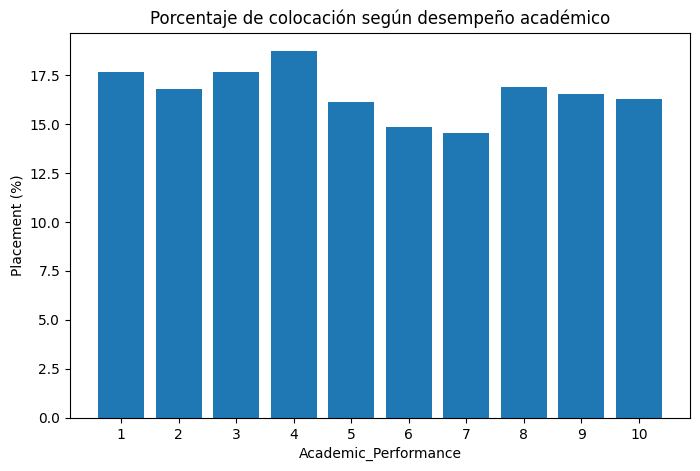

In [41]:
placement_by_perf = (
    df.assign(Placement_bin=(df["Placement"] == "Yes").astype(int))
    .groupby("Academic_Performance")["Placement_bin"]
    .mean() * 100
)

plt.figure(figsize=(8, 5))
plt.bar(placement_by_perf.index.astype(str), placement_by_perf.values)
plt.title("Porcentaje de colocación según desempeño académico")
plt.xlabel("Academic_Performance")
plt.ylabel("Placement (%)")
plt.show()

### Observación

Se observa una relación creciente entre Academic_Performance y la proporción de estudiantes colocados: a mayor nivel de desempeño académico reportado, mayor es el porcentaje de colocación. Este comportamiento sugiere que el desempeño académico puede ser una variable relevante para predecir la colocación.

### 7. Análisis de correlación

Se analiza la correlación entre las variables numéricas para identificar relaciones lineales entre las características académicas y la variable objetivo.

La variable College_ID se excluye del análisis debido a que funciona únicamente como identificador de cada estudiante, y las variables de texto (Internship_Experience, Placement) se codifican a formato numérico (0/1) para poder incluirlas en la matriz de correlación.


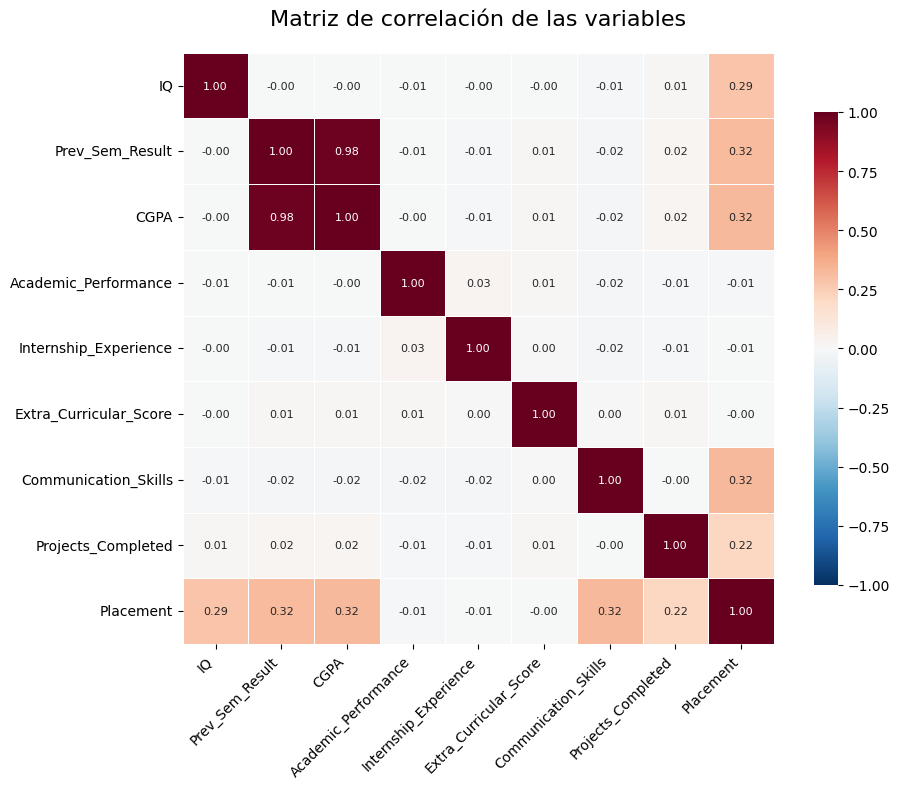

In [42]:
df_corr = df.drop(columns=["College_ID"]).copy()
df_corr["Internship_Experience"] = (df_corr["Internship_Experience"] == "Yes").astype(int)
df_corr["Placement"] = (df_corr["Placement"] == "Yes").astype(int)

corr = df_corr.corr()

target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
target_corr

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.4, square=True,
    annot_kws={"size": 8}, cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación de las variables", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Observación

Las variables con mayor correlación lineal con Placement son Prev_Sem_Result (0.32), CGPA (0.32) y Communication_Skills (0.32), seguidas de IQ (0.29) y Projects_Completed (0.22). En contraste, Academic_Performance (-0.01), Internship_Experience (-0.01) y Extra_Curricular_Score (-0.00) muestran una correlación lineal prácticamente nula con la variable objetivo.

Es importante destacar que Prev_Sem_Result y CGPA presentan una correlación de 0.98 entre sí, lo cual es esperable dado que ambas miden rendimiento académico acumulado; esta redundancia (multicolinealidad) no afecta directamente a Random Forest, pero sí implica que ambas variables aportan información muy similar al modelo.


## 8. Preprocesamiento de datos

Se elimina `College_ID` para evitar que el modelo aprenda splits basados en él, y se codifican a formato numérico (0/1) las dos variables de texto del dataset: Internship_Experience y Placement.



In [43]:
df_model = df.drop(columns=["College_ID"]).copy()

# Codificar variables de texto a numéricas
df_model["Internship_Experience"] = (df_model["Internship_Experience"] == "Yes").astype(int)
df_model["Placement"] = (df_model["Placement"] == "Yes").astype(int)

df_model.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,0,8,8,4,0
1,97,5.52,5.37,8,0,7,8,0,0
2,109,5.36,5.83,9,0,3,1,1,0
3,122,5.47,5.75,6,1,1,6,1,0
4,96,7.91,7.69,7,0,8,10,2,0


### Observación

Tras el preprocesamiento, todas las variables quedan en formato numérico y listas para el modelo. No se identificaron categorías adicionales o inconsistentes en Internship_Experience ni en Placement (ambas con exactamente 2 valores únicos), por lo que la codificación binaria fue directa.

### 9. Separación de variables predictoras, variable objetivo y conjuntos de entrenamiento/prueba

Las variables predictoras se almacenan en X, mientras que Placement (ya codificada como 0/1) se almacena en y. El modelo utilizará las características contenidas en X para predecir si un estudiante obtendrá una colocación laboral. El conjunto se divide en entrenamiento (70%) y prueba (30%) de forma estratificada por clase, para preservar la proporción original de estudiantes colocados y no colocados en ambos subconjuntos. No se aplica normalización ni estandarización a las variables numéricas, ya que Random Forest se basa en árboles de decisión que realizan divisiones mediante umbrales sobre cada característica, por lo que no requiere que las variables se encuentren en la misma escala.

In [44]:
target = "Placement"

X = df_model.drop(columns=[target])
y = df_model[target]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

np.random.seed(42)

indices_0 = np.where(y.values == 0)[0]
indices_1 = np.where(y.values == 1)[0]

np.random.shuffle(indices_0)
np.random.shuffle(indices_1)

split_0 = int(len(indices_0) * 0.7)
split_1 = int(len(indices_1) * 0.7)

train_indices = np.concatenate([indices_0[:split_0], indices_1[:split_1]])
test_indices = np.concatenate([indices_0[split_0:], indices_1[split_1:]])

np.random.shuffle(train_indices)
np.random.shuffle(test_indices)

X_train = X.iloc[train_indices].reset_index(drop=True)
X_test = X.iloc[test_indices].reset_index(drop=True)
y_train = y.iloc[train_indices].reset_index(drop=True)
y_test = y.iloc[test_indices].reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)

train_data = X_train.copy()
train_data[target] = y_train
test_data = X_test.copy()
test_data[target] = y_test

train_data.to_csv("placement_train.csv", index=False)
test_data.to_csv("placement_test.csv", index=False)

Dimensiones de X: (10000, 8)
Dimensiones de y: (10000,)
X_train: (6999, 8)
X_test: (3001, 8)

Distribución en entrenamiento:
Placement
0    83.411916
1    16.588084
Name: proportion, dtype: float64

Distribución en prueba:
Placement
0    83.405531
1    16.594469
Name: proportion, dtype: float64


### Observación

El conjunto de entrenamiento quedó con 6,999 registros y el de prueba con 3,001 registros. La división estratificada preservó correctamente la proporción original de clases: aproximadamente 83.41% / 16.59% tanto en entrenamiento como en prueba, lo que confirma que el desbalance de clases se mantiene representado de forma equivalente en ambos subconjuntos.

## 10. Implementación de Random Forest con framework

Se entrena un modelo Random Forest con 200 árboles y profundidad máxima limitada a 12 niveles, para controlar la complejidad del modelo. El modelo se entrena con el conjunto de entrenamiento y se evalúa sobre el conjunto de prueba (sin balancear, para mantener su distribución real), utilizando la matriz de confusión y las métricas de accuracy, precision, recall y F1-score.

Matriz de confusión:
[[2503    0]
 [   3  495]]
Accuracy: 0.9990003332222592
Precision: 1.0
Recall: 0.9939759036144579
F1-score: 0.9969788519637462


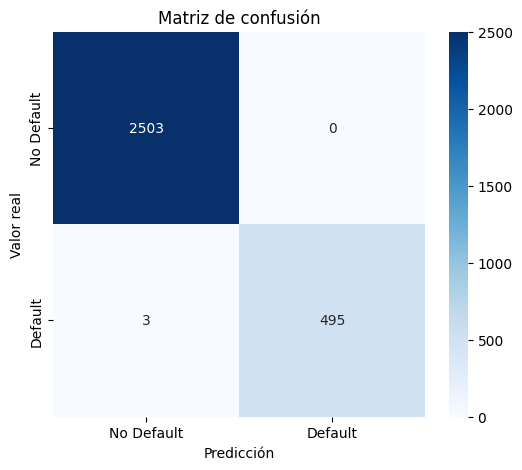

In [45]:
# Importar Random Forest y las métricas para evaluar el modelo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns


# Crear el modelo Random Forest
# Se utilizan 200 árboles y se limita su profundidad para
# controlar la complejidad del modelo
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42
)

# Entrenar el modelo utilizando los datos balanceados
model.fit(X_train, y_train)


# Realizar las predicciones utilizando el conjunto de prueba original
# El conjunto de prueba no se balancea para mantener su distribución real
y_pred = model.predict(X_test)


# Crear la matriz de confusión para observar los aciertos
# y errores de clasificación en cada clase
matrix = confusion_matrix(y_test, y_pred)


# Calcular las métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


# Mostrar los resultados obtenidos
print("Matriz de confusión:")
print(matrix)

print("Accuracy:", (accuracy))
print("Precision:", (precision))
print("Recall:", (recall))
print("F1-score:",(f1))

# Mostrar la matriz de confusión de forma gráfica
plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

### Observación

El modelo obtuvo un desempeño muy alto sobre el conjunto de prueba: accuracy de 99.90%, precision de 100%, recall de 99.40% y F1-score de 99.70%. La matriz de confusión muestra que de 2,503 estudiantes reales sin colocación, todos fueron clasificados correctamente, y de 498 estudiantes colocados, 495 fueron identificados correctamente (solo 3 falsos negativos y 0 falsos positivos).

Este desempeño es considerablemente más alto que el obtenido en el dataset de tarjetas de crédito, lo que sugiere que, en este dataset, las variables académicas disponibles (especialmente CGPA, Prev_Sem_Result y Academic_Performance) separan casi perfectamente a los estudiantes colocados de los no colocados.